In [1]:
from datasets import load_dataset, DatasetDict

hf_nature_ds = load_dataset("mertcobanov/nature-dataset")
split = hf_nature_ds["train"].train_test_split(test_size=0.4, seed=42)
hf_nature_unseperated_ds = DatasetDict({
    "train": split["train"],
    "validation\test": split["test"]
})
validation_test_split = hf_nature_unseperated_ds["validation\test"].train_test_split(test_size=0.5, seed=42)
hf_nature_ds = DatasetDict({
    "train": hf_nature_unseperated_ds["train"],
    "validation": validation_test_split["train"],
    "test": validation_test_split["test"]
})
hf_nature_ds

README.md:   0%|          | 0.00/406 [00:00<?, ?B/s]

data/train-00000-of-00005-e93cb538dd6e75(…):   0%|          | 0.00/513M [00:00<?, ?B/s]

data/train-00001-of-00005-a70efa7808d4d2(…):   0%|          | 0.00/524M [00:00<?, ?B/s]

data/train-00002-of-00005-b9a06f86c921b2(…):   0%|          | 0.00/520M [00:00<?, ?B/s]

data/train-00003-of-00005-b0d241758db4d2(…):   0%|          | 0.00/539M [00:00<?, ?B/s]

data/train-00004-of-00005-867c118c76edb3(…):   0%|          | 0.00/517M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'caption'],
        num_rows: 30000
    })
    validation: Dataset({
        features: ['image', 'caption'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['image', 'caption'],
        num_rows: 10000
    })
})

In [2]:
from datasets import load_dataset, DatasetDict
import re

# More precise: require the obstacle to be the SUBJECT, not incidental
NON_TRAVERSIBLE_SUBJECTS = {
    "ocean", "lake", "river", "flood", "lava", "quicksand", "glacier", "chasm"
}

# Context-aware: these only block if no path/trail word is present
CONDITIONAL_BLOCKERS = {
    "water", "cliff", "steep", "snow", "ice", "swamp", "marsh"
}

TRAVERSIBLE_INDICATORS = {
    "path", "trail", "road", "track", "walkway", "bridge",
    "sidewalk", "pavement", "steps", "stairs"
}
from datasets import load_dataset, DatasetDict
import re

# More precise: require the obstacle to be the SUBJECT, not incidental
NON_TRAVERSIBLE_SUBJECTS = {
    "ocean", "lake", "river", "flood", "lava", "quicksand", "glacier", "chasm"
}

# Context-aware: these only block if no path/trail word is present
CONDITIONAL_BLOCKERS = {
    "water", "cliff", "steep", "snow", "ice", "swamp", "marsh"
}

TRAVERSIBLE_INDICATORS = {
    "path", "trail", "road", "track", "walkway", "bridge",
    "sidewalk", "pavement", "steps", "stairs"
}

def label_traversibility(example):
    caption = example["caption"].lower()
    words = set(re.findall(r'\b\w+\b', caption))

    has_traversible = bool(words & TRAVERSIBLE_INDICATORS)
    has_hard_blocker = bool(words & NON_TRAVERSIBLE_SUBJECTS)
    has_conditional = bool(words & CONDITIONAL_BLOCKERS)

    is_not_traversible = has_hard_blocker or (has_conditional and not has_traversible)
    return {"label": 0 if is_not_traversible else 1}

hf_nature_ds = hf_nature_ds.map(label_traversibility)
hf_nature_ds = hf_nature_ds.remove_columns("caption")
hf_nature_ds

def label_traversibility(example):
    caption = example["caption"].lower()
    words = set(re.findall(r'\b\w+\b', caption))

    has_traversible = bool(words & TRAVERSIBLE_INDICATORS)
    has_hard_blocker = bool(words & NON_TRAVERSIBLE_SUBJECTS)
    has_conditional = bool(words & CONDITIONAL_BLOCKERS)

    is_not_traversible = has_hard_blocker or (has_conditional and not has_traversible)
    return {"label": 0 if is_not_traversible else 1}

hf_nature_ds = hf_nature_ds.map(label_traversibility)
hf_nature_ds = hf_nature_ds.remove_columns("caption")
hf_nature_ds


Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 30000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

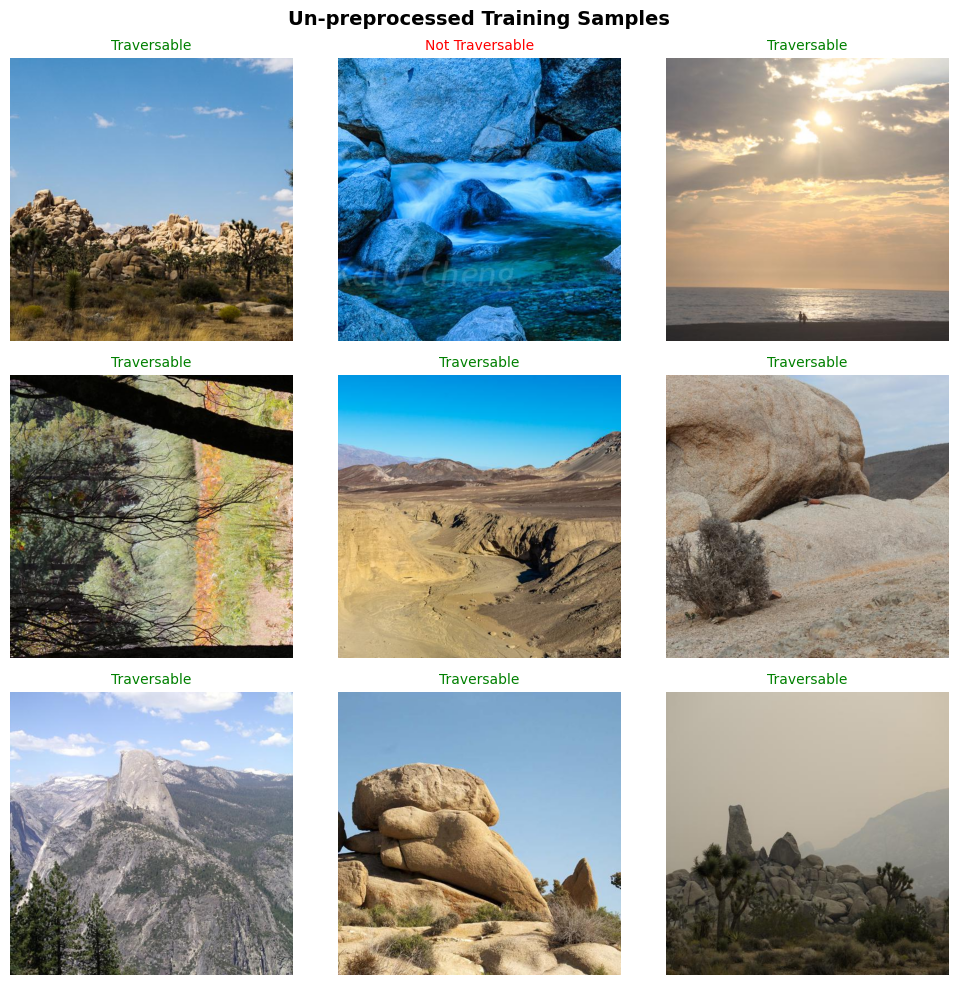

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_samples(dataset, num_samples=9, cols=3):
    rows = num_samples // cols
    fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
    fig.suptitle("Un-preprocessed Training Samples", fontsize=14, fontweight="bold")

    # Grab a batch of samples
    samples = dataset["train"].shuffle(seed=42).select(range(num_samples))

    for i, example in enumerate(samples):
        ax = axes[i // cols, i % cols]

        image = np.array(example["image"])
        label = example["label"]
        label_name = "Traversable" if label == 1 else "Not Traversable"

        # Squeeze grayscale channel dim (92, 92, 1) → (92, 92)
        ax.imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(label_name, fontsize=10,
                     color="green" if label == 1 else "red")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("training_samples.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_training_samples(hf_nature_ds)

In [4]:
import os
import tensorflow as tf
from tensorflow.data import Dataset as TFDataset
num_cpus = os.cpu_count() if os.cpu_count() is not None else 1
# Now, split into training and validation tensorflow datasets
train_nature_ds: TFDataset = hf_nature_ds["train"].to_tf_dataset(
    columns="image",
    label_cols="label",
    batch_size=32,
    shuffle=True
)
validation_nature_ds: TFDataset = hf_nature_ds["validation"].to_tf_dataset(
    columns="image",
    label_cols="label",
    batch_size=32,
    shuffle=False
)
test_nature_ds: TFDataset = hf_nature_ds["test"].to_tf_dataset(
    columns="image",
    label_cols="label",
    batch_size=32,
    shuffle=False
)
train_nature_ds, validation_nature_ds, test_nature_ds

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 512, 512, 3), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 512, 512, 3), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 512, 512, 3), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

In [5]:
import cv2
import numpy as np
import tensorflow as tf # Ensure tf is imported for tf.cast

def preprocess(image, label):
    # Convert to grayscale (H, W, 1)
    image = tf.image.rgb_to_grayscale(image)
    # Resize to (92, 92)
    image = tf.image.resize(image, (92, 92))
    # Cast to uint8 for space
    image = tf.cast(image, tf.float32) / 255.0
    # label shape = (32, 1)
    return image, label

# Apply preprocess to individual images, then batch and prefetch
train_nature_ds = train_nature_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
validation_nature_ds = validation_nature_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
test_nature_ds = test_nature_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)

# Expand labels to leave TensorSpec(shape=(None, )) to TensorSpec(shape=(None, 1)), allowing for tensorflow metrics
def expand_labels(image, label):
    label = tf.expand_dims(label, axis=-1)
    return image, label

train_nature_ds = train_nature_ds.map(expand_labels)
validation_nature_ds = validation_nature_ds.map(expand_labels)
test_nature_ds = test_nature_ds.map(expand_labels)

train_nature_ds, validation_nature_ds, test_nature_ds

(<_MapDataset element_spec=(TensorSpec(shape=(None, 92, 92, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.int64, name=None))>,
 <_MapDataset element_spec=(TensorSpec(shape=(None, 92, 92, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.int64, name=None))>,
 <_MapDataset element_spec=(TensorSpec(shape=(None, 92, 92, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.int64, name=None))>)

In [6]:
image, label = next(iter(train_nature_ds))

image.shape

TensorShape([32, 92, 92, 1])

In [7]:
num_traversible, num_not_traversible = 0, 0
images_traversed = 0
for(image, label) in train_nature_ds.unbatch():
    if label == 1:
        num_traversible += 1
    else:
        num_not_traversible += 1
    images_traversed += 1
    if(images_traversed % 1000 == 0):
      print(f"Processed {images_traversed}")
num_traversible, num_not_traversible

Processed 1000
Processed 2000
Processed 3000
Processed 4000
Processed 5000
Processed 6000
Processed 7000
Processed 8000
Processed 9000
Processed 10000
Processed 11000
Processed 12000
Processed 13000
Processed 14000
Processed 15000
Processed 16000
Processed 17000
Processed 18000
Processed 19000
Processed 20000
Processed 21000
Processed 22000
Processed 23000
Processed 24000
Processed 25000
Processed 26000
Processed 27000
Processed 28000
Processed 29000
Processed 30000


(23560, 6440)

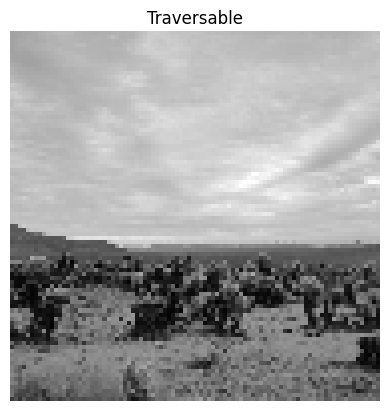

In [8]:
plt.imshow(image.numpy(), cmap="gray")
plt.title("Traversable" if label[0] == 1 else "Not Traversable")
plt.axis("off")
plt.show()

In [9]:
# Verify your dataset is returning correct image-label pairs
for images, labels in train_nature_ds.take(1):
    print("Image shape:", images.shape)   # should be (batch, 92, 92, 3)
    print("Label shape:", labels.shape)   # should be (batch,)
    print("Label values:", labels[:10])   # should be mix of 0s and 1s
    print("Image min/max:", tf.reduce_min(images), tf.reduce_max(images))
    # Image values should be between 0 and 1 — if max is 255 that's your problem

Image shape: (32, 92, 92, 1)
Label shape: (32, 1)
Label values: tf.Tensor(
[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]], shape=(10, 1), dtype=int64)
Image min/max: tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(0.99607843, shape=(), dtype=float32)


In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same", input_shape=(92, 92, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation="sigmoid")
], name="TinyVGG")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "TinyVGG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 92, 92, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 46, 46, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,833 (18.88 KB)

 Trainable params: 4,833 (18.88 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compile the model & Run the epochs
EPOCHS: int = 20

class_weight = {
    0: 30000 / (2 * num_not_traversible),  # minority gets higher weight
    1: 30000 / (2 * num_traversible)
}
# >> {0: 2.0, 1: 0.67} for a 75/25 split

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"), # of all predicted positives, how many were correct
        tf.keras.metrics.Recall(name="recall"), # of all true positives, how many were predicted
        tf.keras.metrics.AUC(name="auc"), # area under ROC curve 1.0 = perfect, 0.5 = random
        tf.keras.metrics.F1Score(threshold=0.5)
    ]
)

model.fit(
    train_nature_ds,
    class_weight=class_weight,
    validation_data=validation_nature_ds,
    epochs=EPOCHS
)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 793s 835ms/step - accuracy: 0.5236 - auc: 0.5240 - f1_score: 0.6350 - loss: 0.6923 - precision: 0.7971 - recall: 0.5278 - val_accuracy: 0.4956 - val_auc: 0.5432 - val_f1_score: 0.5920 - val_loss: 0.6883 - val_precision: 0.8018 - val_recall: 0.4693
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 801s 842ms/step - accuracy: 0.4930 - auc: 0.5516 - f1_score: 0.5885 - loss: 0.6882 - precision: 0.8115 - recall: 0.4617 - val_accuracy: 0.5987 - val_auc: 0.5615 - val_f1_score: 0.7185 - val_loss: 0.6648 - val_precision: 0.7932 - val_recall: 0.6566
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 785s 837ms/step - accuracy: 0.5031 - auc: 0.5786 - f1_score: 0.5938 - loss: 0.6835 - precision: 0.8294 - recall: 0.4624 - val_accuracy: 0.6300 - val_auc: 0.5909 - val_f1_score: 0.7456 - val_loss: 0.6527 - val_precision: 0.8038 - val_recall: 0.6953
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 790s 842ms/step - accuracy: 0.5149 - auc: 0.6024 - f1_score: 0.6063 - loss: 0.6771 - precision: 

In [12]:
model.evaluate(test_nature_ds)

313/313 ━━━━━━━━━━━━━━━━━━━━ 202s 643ms/step - accuracy: 0.6453 - auc: 0.6940 - f1_score: 0.7405 - loss: 0.6412 - precision: 0.8663 - recall: 0.6467


[0.6411700248718262,
 0.6452999711036682,
 0.8663358092308044,
 0.6466530561447144,
 0.6940031051635742,
 0.7405456900596619]

In [14]:
# Quantize
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save to Google Drive
from google.colab import drive
drive.mount('/content/drive')

with open("/content/drive/MyDrive/tinyvgg_terrain_quantized_2.tflite", "wb") as f:
    f.write(tflite_model)

print(f"Quantized model size: {len(tflite_model) / 1024:.2f} KB")
print("Model saved to Google Drive!")

Saved artifact at '/tmp/tmpttfau__q'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 92, 92, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136197357900560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136188706234320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136188706235856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136188706235280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136188706231824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136188706232016: TensorSpec(shape=(), dtype=tf.resource, name=None)
Mounted at /content/drive
Quantized model size: 8.61 KB
Model saved to Google Drive!
